In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_transaction = pd.read_csv("transaction_cleaned.csv")
df_campaign_info = pd.read_csv("campaign_info_cleaned.csv")
df_referral = pd.read_csv("referral_history_cleaned.csv")

In [3]:
dataframe = df_campaign_info[df_campaign_info['campaignCode'] == 'ZPI_220801_115'][['campaignID', 'campaignCode']]
dataframe

,campaignID,campaignCode
0,8907,ZPI_220801_115
1,8945,ZPI_220801_115
30,9268,ZPI_220801_115
36,8904,ZPI_220801_115
40,8939,ZPI_220801_115
...,...,...
770,8906,ZPI_220801_115
775,8908,ZPI_220801_115
810,8942,ZPI_220801_115
811,9080,ZPI_220801_115


In [4]:
filtered_transaction = df_transaction[df_transaction['campaignID'].isin(dataframe['campaignID'])]
filtered_transaction.info()

<class 'pandas.core.frame.DataFrame'>
Index: 309254 entries, 0 to 1357386
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transID           309254 non-null  object 
 1   userID            309254 non-null  object 
 2   appID             215884 non-null  float64
 3   transStatus       309254 non-null  int64  
 4   deviceID          209563 non-null  object 
 5   platform          215884 non-null  object 
 6   userChargeAmount  309254 non-null  int64  
 7   amount            309254 non-null  int64  
 8   reqDate           309254 non-null  object 
 9   campaignID        309254 non-null  int64  
 10  discountAmount    309254 non-null  int64  
 11  cashbackTime      93381 non-null   object 
dtypes: float64(1), int64(5), object(6)
memory usage: 30.7+ MB


In [5]:
filtered_transaction.to_csv("filtered_transaction.csv", index = False)

In [6]:
# Chuyển đổi cột reqDate sang kiểu datetime
df_referral['reqDate'] = pd.to_datetime(df_referral['reqDate'])

# Tìm thời gian sớm nhất và trễ nhất
earliest_time = df_referral['reqDate'].min()
latest_time = df_referral['reqDate'].max()

# In ra kết quả
print("Thời gian sớm nhất:", earliest_time)
print("Thời gian trễ nhất:", latest_time)

Thời gian sớm nhất: 2022-03-02 00:00:25
Thời gian trễ nhất: 2022-05-31 23:59:40


Ta thấy thời gian trong bảng dữ liệu này nằm trong thời gian diễn ra chiến dịch giới thiệu bạn bè qua thẻ liên kết Zalopay

In [7]:
# Lọc ra những user nằm trong chiến dịch
userID_df_referral = df_referral[['userID']].drop_duplicates()
refereeId_df_referral = df_referral[['refereeId']].drop_duplicates().rename(columns={'refereeId': 'userID'})
userID_df_transaction = filtered_transaction[['userID']].drop_duplicates()

In [8]:
combined = pd.concat([userID_df_referral, refereeId_df_referral, userID_df_transaction], ignore_index=True)

In [9]:
user_in_campaign = combined.drop_duplicates()

In [10]:
# Số lượng user trong chiến dịch giới thiệu bạn bè qua thẻ liên kết zalopay
len(user_in_campaign)

864342

In [11]:
user_in_campaign.to_csv("userID_in_campaign.csv", index=False)

In [12]:
result = pd.read_csv("userID_in_campaign.csv")

In [13]:
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864342 entries, 0 to 864341
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   userID  864342 non-null  object
dtypes: object(1)
memory usage: 6.6+ MB


## Sign-up bonus abuse

In [14]:
df_rm = pd.read_csv("referral_history_cleaned.csv")

In [15]:
# Chuyển reqDate sang kiểu datetime
df_rm['reqDate'] = pd.to_datetime(df_rm['reqDate'])

# Sắp xếp dữ liệu theo userID, refereeId và reqDate
df_sorted = df_rm.sort_values(by=['userID', 'refereeId', 'reqDate'])

# Xóa những dòng trùng userID và refereeId nhưng khác thời gian, chỉ giữ lại dòng có thời gian sớm nhất
df_filtered = df_sorted.drop_duplicates(subset=['userID', 'refereeId'], keep='first')
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 555463 entries, 55294 to 379113
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   userID     555463 non-null  object        
 1   refereeId  555463 non-null  object        
 2   reqDate    555463 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(2)
memory usage: 17.0+ MB


In [16]:
# Nhóm theo userID và tính số lượng lời mời cho mỗi userID
userID_counts = df_filtered['userID'].value_counts()

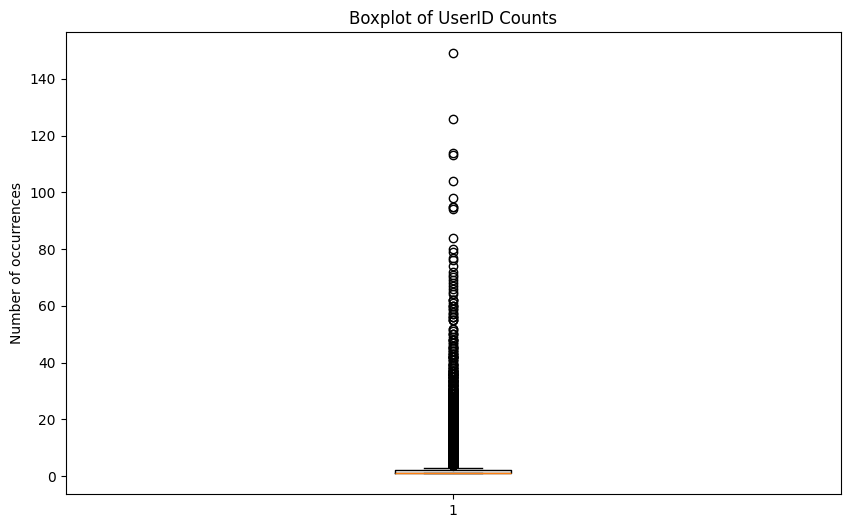

In [17]:
# Vẽ boxplot để phân tích số lượng lời mời của mỗi userID
plt.figure(figsize=(10, 6))
plt.boxplot(userID_counts)
plt.title('Boxplot of UserID Counts')
plt.ylabel('Number of occurrences')
plt.show()

In [18]:
# Tính IQR (Interquartile Range)
Q1 = userID_counts.quantile(0.25)
Q3 = userID_counts.quantile(0.75)
IQR = Q3 - Q1

# Xác định các giới hạn để phát hiện outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Ngưỡng outlier (Q3 + 1.5×IQR) = {upper_bound:.2f}")


Ngưỡng outlier (Q3 + 1.5×IQR) = 3.50


In [32]:
# Lọc các userID có số lượng lời mời ngoài khoảng (outliers)
outliers = userID_counts[(userID_counts < lower_bound) | (userID_counts > upper_bound)]

# Lọc các userID là outliers 
outlier_user_ids = outliers.index

# Lọc DataFrame df_filtered để chỉ lấy các userID là outliers
df_outliers = df_filtered[df_filtered['userID'].isin(outlier_user_ids)]

# Sắp xếp lại df_filtered theo userID và reqDate
df_outliers = df_outliers.sort_values(by=['userID', 'reqDate'])

# Tính thời gian chênh lệch giữa các lời mời theo userID
df_outliers['time_diff'] = df_outliers.groupby('userID')['reqDate'].diff()

# Tính thời gian trung bình của các lời mời cho mỗi user
avg_time_per_user = df_outliers.groupby('userID')['time_diff'].mean()

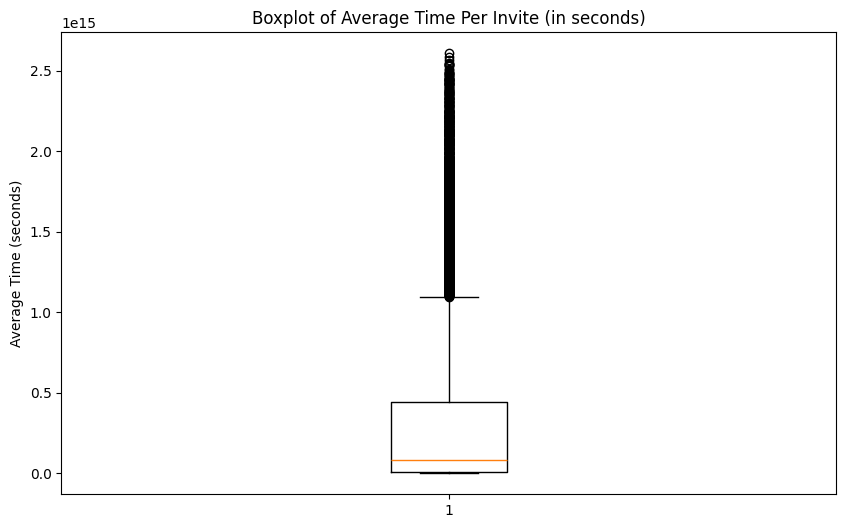

In [33]:
# Vẽ boxplot cho thời gian trung bình
plt.figure(figsize=(10, 6))
plt.boxplot(avg_time_per_user)
plt.title('Boxplot of Average Time Per Invite (in seconds)')
plt.ylabel('Average Time (seconds)')
plt.show()


Ta thấy phần lớn các userID thực hiện lời mời trong thời gian rất ngắn khả năng cao là bot, ngoài ra những user "bình thường" sẽ có thời gian thực hiện hết "tất cả" lời mời sẽ lâu hơn nhiều so với bot nên làm cho biểu đồ rất lệch phải => Ta dùng mô hình KMeans Clustering để phân cụm dữ liệu giúp xác định những user có hành vi bất thường

In [36]:
avg_time_per_user = df_outliers.groupby('userID')['time_diff'].mean().reset_index()
userID_counts = df_filtered['userID'].value_counts().reset_index()
df = avg_time_per_user.merge(userID_counts, on='userID', how='left')
df['time_diff'] = df['time_diff'].dt.total_seconds()

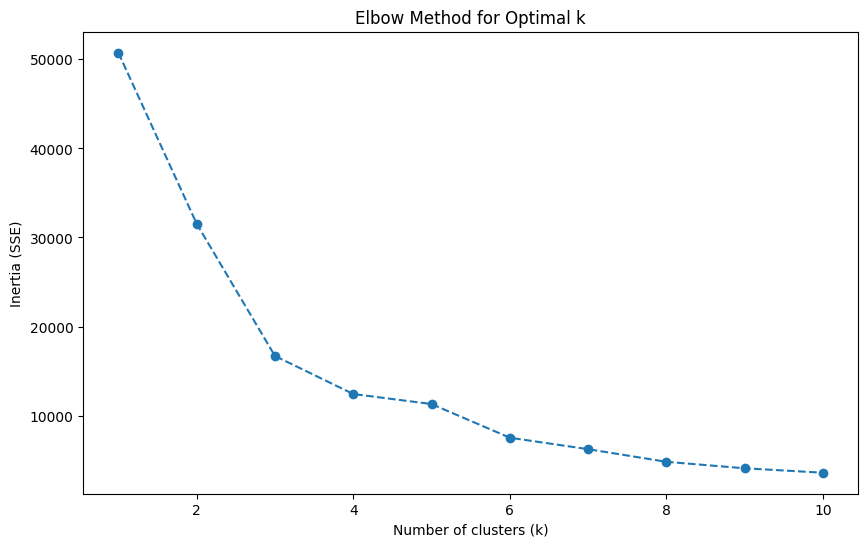

In [39]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Bước 1: Chuẩn hóa dữ liệu (scaling) để đưa các giá trị về cùng một phạm vi
scaler = StandardScaler()
df_outliers_scaled = scaler.fit_transform(df[['time_diff', 'count']]) 

# Bước 2: Áp dụng KMeans và thử các giá trị khác nhau của k
inertia = [] 

# Thử từ k = 1 đến k = 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_outliers_scaled)
    inertia.append(kmeans.inertia_)

# Bước 3: Vẽ Elbow Method để chọn k tối ưu
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.show()


Biểu đồ "Elbow Method" này thể hiện mối quan hệ giữa số lượng cụm (k) và tổng bình phương sai số (SSE). SSE giảm mạnh khi tăng k từ 1 đến 3, sau đó tốc độ giảm dần khi số lượng cụm tăng thêm. Vì vậy ta chọn k = 3 để có số cụm tối ưu

In [40]:
from sklearn.cluster import KMeans

# Áp dụng KMeans với k=3 (số cụm tối ưu)
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(df_outliers_scaled)

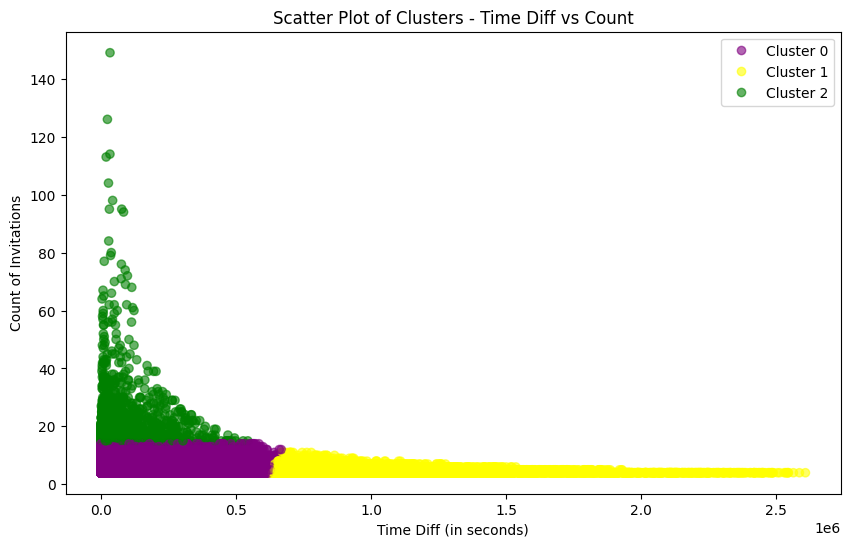

In [41]:
from matplotlib.colors import ListedColormap 

plt.figure(figsize=(10, 6))
cmap = ListedColormap(['purple', 'yellow', 'green'])

# Vẽ scatter plot với
scatter = plt.scatter(df['time_diff'], df['count'], c=df['cluster'], cmap=cmap, alpha=0.6)
plt.title('Scatter Plot of Clusters - Time Diff vs Count')
plt.xlabel('Time Diff (in seconds)')
plt.ylabel('Count of Invitations')
plt.legend(handles=scatter.legend_elements()[0], labels=['Cluster 0', 'Cluster 1', 'Cluster 2'], loc='upper right')
plt.show()

Cluster 1 và 0: Hai nhóm còn lại có thể là người thật, vì họ có số lần mời thấp hơn và thời gian thực hiện giao dịch dài hơn, điều này thể hiện hành vi tự nhiên của người dùng. Cluster 2 (màu xanh lá): Hành vi của nhóm này có vẻ là bot. Điều này có thể được giả định vì thời gian thực hiện giao dịch rất ngắn, nhưng lại có số lượng mời rất cao.

In [42]:
# Gán nhãn "Sign-up bonus abuse" cho các userID ngờ là bot
result['sign_up_bonus_abuse'] = result['userID'].isin(df[df['cluster'] == 2]['userID']).astype(int)

In [43]:
result['sign_up_bonus_abuse'].value_counts()

sign_up_bonus_abuse
0    862662
1      1680
Name: count, dtype: int64

In [44]:
# Tính tỷ lệ các userID ngờ là bot trong toàn bộ dữ liệu
bot_ratio = result['sign_up_bonus_abuse'].mean()
# In tỷ lệ của bot
print(f"Tỷ lệ userID ngờ là bot: {bot_ratio:.2%}")

Tỷ lệ userID ngờ là bot: 0.19%


## Duplicate timestamp

In [45]:
df_tx = filtered_transaction.copy()
df_tx = filtered_transaction[filtered_transaction['transStatus'] == 1]

In [46]:
# Đếm số lượng transID duy nhất tại mỗi timestamp theo user
trans_counts = (
    df_tx.groupby(['userID', 'reqDate'])['transID']
      .nunique()
      .reset_index(name='unique_trans_count')
)

In [47]:
# Lấy số transID khác nhau ít nhất mỗi user từng có tại 1 thời điểm
min_unique_trans_per_user = (
    trans_counts.groupby('userID')['unique_trans_count']
                .min()
                .reset_index(name='min_unique_trans')
)

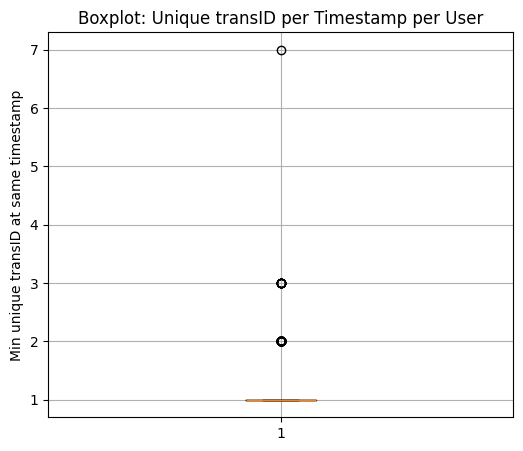

In [48]:
# Vẽ Box-plot và áp dụng quy tắc IQR để tìm ngưỡng outlier
plt.figure(figsize=(6, 5))
plt.boxplot(min_unique_trans_per_user['min_unique_trans'], vert=True)
plt.ylabel('Min unique transID at same timestamp')
plt.title('Boxplot: Unique transID per Timestamp per User')
plt.grid(True)
plt.show()

In [49]:
q1, q3 = min_unique_trans_per_user['min_unique_trans'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
print(f"Ngưỡng outlier (Q3 + 1.5×IQR) = {upper_bound:.2f}")

Ngưỡng outlier (Q3 + 1.5×IQR) = 1.00


Ta thấy ngưỡng chặn trên bằng 1 là hợp lí vì không thể có 2 mã giao dịch khác nhau tại cùng 1 thời điểm

In [51]:
# Xác định user vi phạm
offenders = set(min_unique_trans_per_user[min_unique_trans_per_user['min_unique_trans'] > upper_bound]['userID'])

In [52]:
result['duplicate_timestamp'] = result['userID'].isin(offenders).astype(int)

In [53]:
# Tính tỷ lệ
total_users = result['userID'].nunique()
violation_rate = len(offenders) / total_users * 100
print(f"Tỷ lệ user vi phạm duplicate_timestamp: {violation_rate:.2f}%")

Tỷ lệ user vi phạm duplicate_timestamp: 0.01%


## Share bank account

In [55]:
df_map = pd.read_csv("map_card_cleaned.csv")
df_ok = df_map[df_map['requestStatus'] == 1] 

In [56]:
# Đếm bao nhiêu user dùng chung mỗi bimID
bank_user_counts = (
    df_ok.groupby('bimID')['userID']
         .nunique()
         .rename('user_per_bank')
         .reset_index()
)

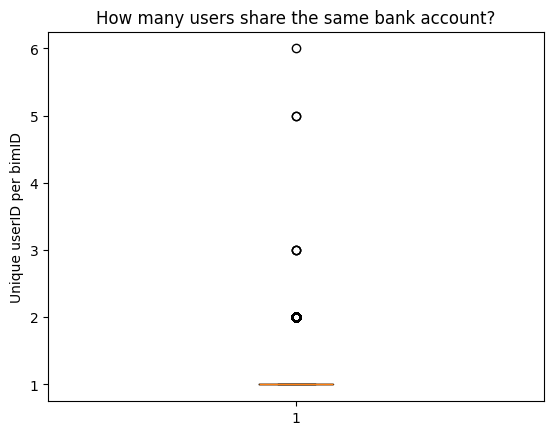

In [57]:
# Box-plot & ngưỡng IQR 
plt.boxplot(bank_user_counts['user_per_bank'])
plt.ylabel('Unique userID per bimID')
plt.title('How many users share the same bank account?')
plt.show()

In [58]:
q1, q3 = bank_user_counts['user_per_bank'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
print(f"Ngưỡng outlier (Q3 + 1.5×IQR) = {upper_bound:.2f}")

Ngưỡng outlier (Q3 + 1.5×IQR) = 1.00


Ta thấy ngưỡng chặn trên bằng 1 là hợp lí vì hiếm khi có 2 người dùng cùng chung 1 tài khoản

In [60]:
# Lấy bimID ngoại lai & userID vi phạm
shared_banks = bank_user_counts[bank_user_counts['user_per_bank'] > upper_bound]['bimID']

offender_ids = set(
    df_ok[df_ok['bimID'].isin(shared_banks)]['userID']
)

In [61]:
# Thêm nhãn vào result
result['shared_bank_account'] = result['userID'].isin(offender_ids).astype(int)

In [62]:
# Tính tỷ lệ vi phạm
total_users = result['userID'].nunique()
violation_rate = len(offender_ids) / total_users * 100
print(f"Tỷ lệ user vi phạm shared_bank_account: {violation_rate:.2f}%")

Tỷ lệ user vi phạm shared_bank_account: 0.06%


## Multi account same device

In [63]:
df_tx = filtered_transaction.copy()

In [64]:
# Đếm số userID duy nhất trên mỗi deviceID
device_user_cnt = (
    df_tx.groupby('deviceID')['userID']
         .nunique()
         .rename('user_per_device')
         .reset_index()
)

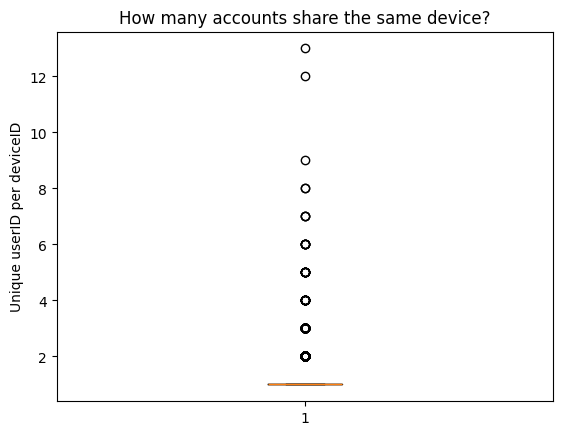

In [65]:
# Box-plot + IQR
plt.boxplot(device_user_cnt['user_per_device'])
plt.ylabel('Unique userID per deviceID')
plt.title('How many accounts share the same device?')
plt.show()

In [66]:
q1, q3 = device_user_cnt['user_per_device'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
print(f"Ngưỡng outlier (Q3 + 1.5×IQR) = {upper_bound:.2f}")

Ngưỡng outlier (Q3 + 1.5×IQR) = 1.00


Ta thấy ngưỡng chặn trên bằng 1 là hợp lí vì thông thường một tài khoản cá nhân chỉ được sử dụng bởi 1 tài khoản duy nhất

In [ ]:
# Lấy deviceID ngoại lai & userID vi phạm
suspicious_devices = device_user_cnt[device_user_cnt['user_per_device'] > upper_bound]['deviceID']

offender_ids = set(
    df_tx[df_tx['deviceID'].isin(suspicious_devices)]['userID']
)

Số userID gắn multi_account_same_device = 1: 1230


In [68]:
# Gắn nhãn vào result
result['multi_account_same_device'] = result['userID'].isin(offender_ids).astype(int)

In [69]:
# Tính tỷ lệ vi phạm
total_users     = result['userID'].nunique()
violating_users = len(offender_ids)
violation_rate  = violating_users / total_users * 100
print(f"Tỷ lệ user vi phạm multi_account_same_device: {violation_rate:.2f}%")

Tỷ lệ user vi phạm multi_account_same_device: 0.14%


## Repeated amount

In [70]:
df_tx = filtered_transaction.copy()
df_tx = df_tx[df_tx['transStatus'] == 1]

In [71]:
# Lọc user chỉ giao dịch ở 1 mức tiền duy nhất
amount_per_user = df_tx.groupby('userID')['amount'].nunique().reset_index()
amount_per_user = amount_per_user[amount_per_user['amount'] == 1]

In [72]:
# Lọc ra userID thoả điều kiện
single_amount_users = set(amount_per_user['userID'])
df_single = df_tx[df_tx['userID'].isin(single_amount_users)]

In [73]:
# Đếm tổng số giao dịch của mỗi user trong nhóm này
txn_counts = df_single.groupby('userID').size().rename('txn_count').reset_index()

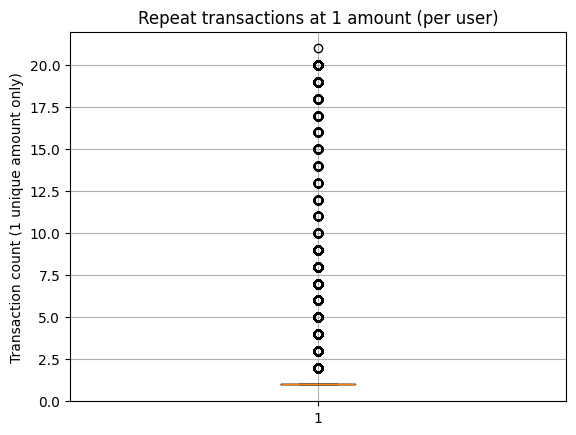

In [74]:
# Vẽ boxplot và xác định outlier bằng IQR
plt.boxplot(txn_counts['txn_count'])
plt.ylabel('Transaction count (1 unique amount only)')
plt.title('Repeat transactions at 1 amount (per user)')
plt.grid(True)
plt.show()

In [75]:
q1, q3 = txn_counts['txn_count'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
print(f"Ngưỡng IQR trên: {upper_bound:.2f}")

Ngưỡng IQR trên: 1.00


Ta thấy upper_bound = 1 thì chỉ cần 2 lần lặp lại 1 mức tiền đã bị xem là outlier, điều này không hợp lý và gây nhiều false positives (người dùng thật cũng dễ bị gắn cờ) => Ta dùng phương pháp percentile với p = 0.95 thay cho IQR

In [76]:
threshold = txn_counts['txn_count'].quantile(0.95)  # top 5%
offenders = set(txn_counts[txn_counts['txn_count'] > threshold]['userID'])
print(f"Số userID gắn repeated_amount = 1: {len(offenders)}")

Số userID gắn repeated_amount = 1: 2573


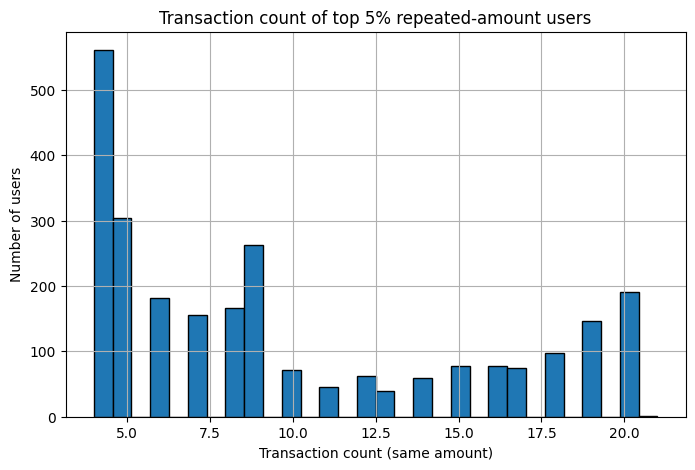

In [77]:
# Vẽ biểu đồ histogram thể hiện số lần giao dịch của những user này
offender_txn_counts = txn_counts[txn_counts['userID'].isin(offenders)]

plt.figure(figsize=(8, 5))
plt.hist(offender_txn_counts['txn_count'], bins=30, edgecolor='black')
plt.xlabel('Transaction count (same amount)')
plt.ylabel('Number of users')
plt.title('Transaction count of top 5% repeated-amount users')
plt.grid(True)
plt.show()

Ta thấy hầu hết user vi phạm top 5% chỉ giao dịch lặp lại 4–8 lần => Chưa hẳn là gian lận. Tuy nhiên, vẫn có cụm nhỏ rõ ràng giao dịch 15–20 lần cùng một mức tiền => rất đáng nghi ngờ. Ta tăng mức p = 0.99

In [78]:
threshold = txn_counts['txn_count'].quantile(0.99) 
offenders = set(txn_counts[txn_counts['txn_count'] > threshold]['userID'])
print(f"Số userID gắn repeated_amount = 1: {len(offenders)}")

Số userID gắn repeated_amount = 1: 761


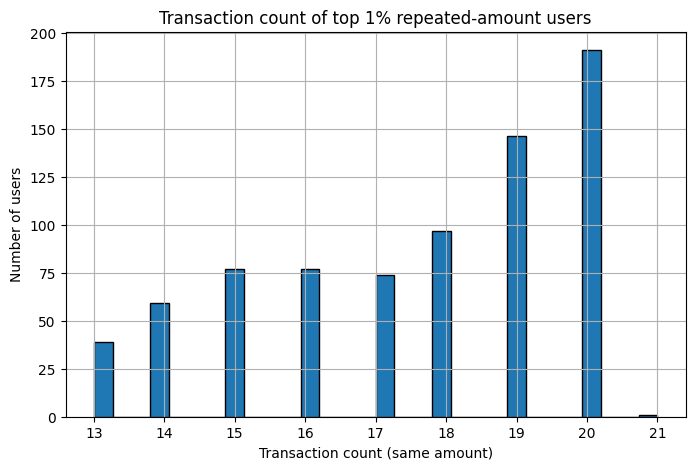

In [79]:
# Vẽ biểu đồ histogram thể hiện số lần giao dịch của những user này
offender_txn_counts = txn_counts[txn_counts['userID'].isin(offenders)]

plt.figure(figsize=(8, 5))
plt.hist(offender_txn_counts['txn_count'], bins=30, edgecolor='black')
plt.xlabel('Transaction count (same amount)')
plt.ylabel('Number of users')
plt.title('Transaction count of top 1% repeated-amount users')
plt.grid(True)
plt.show()

Ta thấy giao dịch lặp lại từ 13 đến 20 lần. Gần như toàn bộ user top 1% đều có hành vi rất rõ ràng, không còn nhiễu từ người thật => Đây là nhóm gian lận rõ rệt, có thể gán nhãn toàn bộ.

In [80]:
# Gán nhãn cho result
result['repeated_amount'] = result['userID'].isin(offenders).astype(int)

In [81]:
# Tính tỷ lệ
total_users = result['userID'].nunique()
violation_rate = len(offenders) / total_users * 100
print(f"Tỷ lệ user vi phạm repeated_amount: {violation_rate:.2f}%")

Tỷ lệ user vi phạm repeated_amount: 0.09%


## Spam transaction

In [82]:
df_tx = filtered_transaction.copy()
df_tx = df_tx[df_tx['transStatus'] == 1]

In [83]:
df_tx['reqDate'] = pd.to_datetime(df_tx['reqDate'])

In [84]:
# Tính tổng số giao dịch của mỗi user
txn_counts = df_tx.groupby('userID').size().reset_index(name='txn_count')

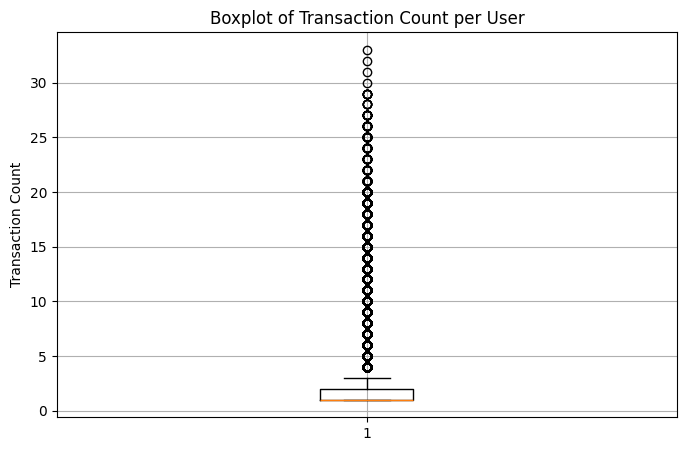

In [85]:
# Vẽ boxplot số lần giao dịch
plt.figure(figsize=(8, 5))
plt.boxplot(txn_counts['txn_count'])
plt.title('Boxplot of Transaction Count per User')
plt.ylabel('Transaction Count')
plt.grid(True)
plt.show()

In [86]:
# Áp dụng IQR để xác định user giao dịch cao bất thường
q1, q3 = txn_counts['txn_count'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

In [87]:
# Lọc ra những user vượt ngưỡng
outlier_users = txn_counts[txn_counts['txn_count'] > upper_bound]

In [88]:
# Tính thời gian từ giao dịch đầu đến cuối của mỗi user (tính bằng giờ)
time_range = (
    df_tx.groupby('userID')['reqDate']
      .agg(['min', 'max'])
      .reset_index()
)
time_range['duration_hours'] = (time_range['max'] - time_range['min']).dt.total_seconds() / 3600

In [89]:
# Gộp hai bảng lại
user_stats = pd.merge(outlier_users, time_range[['userID', 'duration_hours']], on='userID')

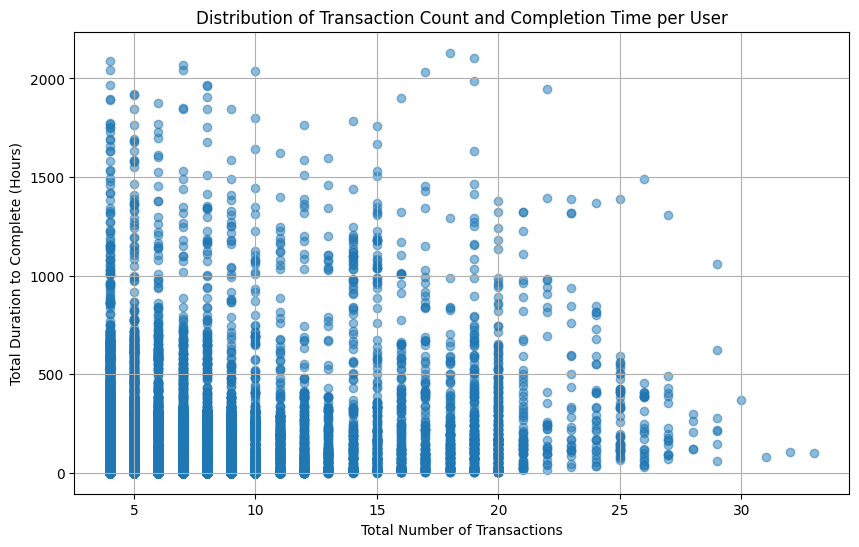

In [90]:
# Vẽ biểu đồ scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(user_stats['txn_count'], user_stats['duration_hours'], alpha=0.5)
plt.xlabel('Total Number of Transactions')
plt.ylabel('Total Duration to Complete (Hours)')
plt.title('Distribution of Transaction Count and Completion Time per User')
plt.grid(True)
plt.show()

Ta phân cụm user bằng KMeans 

In [91]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa dữ liệu
X = user_stats[['txn_count', 'duration_hours']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

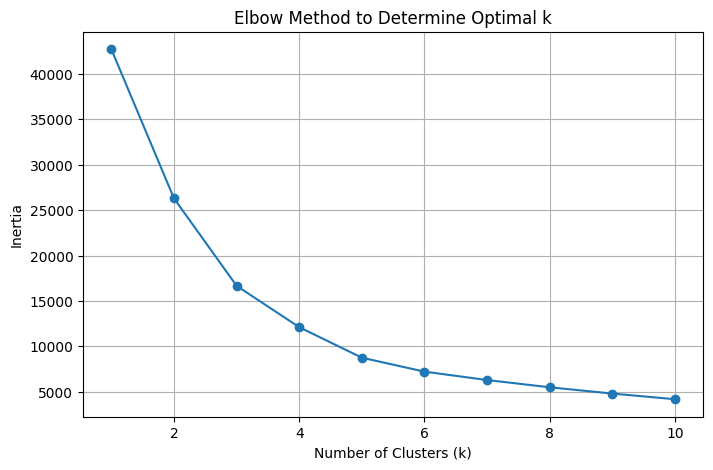

In [92]:
# Elbow method tìm số cụm tối ưu
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Vẽ Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method to Determine Optimal k')
plt.grid(True)
plt.show()

Ta chọn k = 3 để tối ưu theo phương pháp Elbow method

In [93]:
# Áp dụng KMeans với k tối ưu (k = 3)
k_optimal = 3
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

In [94]:
# Gán nhãn cụm vào dữ liệu
user_stats['cluster'] = clusters

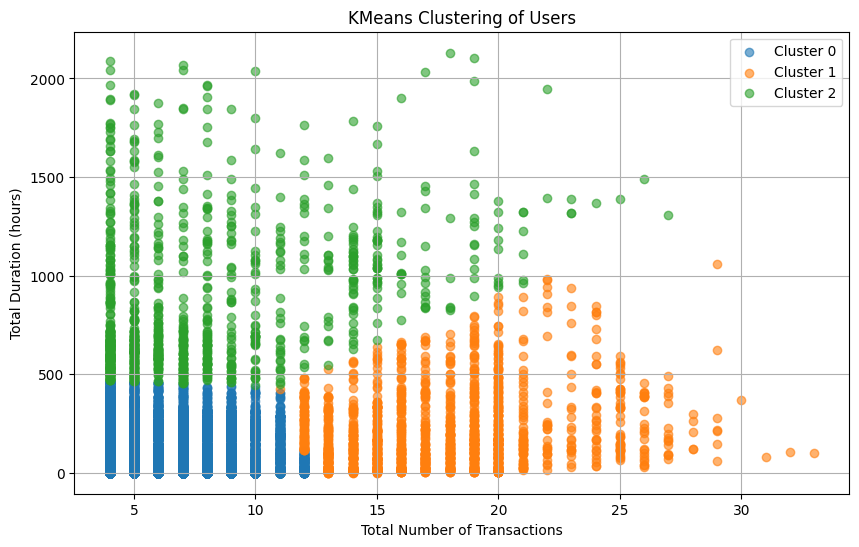

In [95]:
# Vẽ biểu đồ các cụm
plt.figure(figsize=(10, 6))
for cluster_id in range(k_optimal):
    cluster_data = user_stats[user_stats['cluster'] == cluster_id]
    plt.scatter(cluster_data['txn_count'], cluster_data['duration_hours'], label=f'Cluster {cluster_id}', alpha=0.6)

plt.xlabel('Total Number of Transactions')
plt.ylabel('Total Duration (hours)')
plt.title('KMeans Clustering of Users')
plt.legend()
plt.grid(True)
plt.show()

Cụm 0 (màu xanh dương) giao dịch ít so với thời gian thực tế => Khả năng cao là người dùng bình thường, ít hoạt động. Cụm 1 (màu cam) giao dịch cao, thời gian từ thấp đến trung bình => Có khả năng cao là bot / auto script farm giao dịch. Cụm 2 (màu xanh lá) giao dịch trung bình, thời gian rất cao => Giao dịch rải rác qua nhiều ngày, có thể là người dùng thật

In [96]:
# Lấy danh sách userID thuộc Cluster 1 (màu cam)
suspicious_users = user_stats[user_stats['cluster'] == 1]['userID'].unique()

In [97]:
# Gán nhãn cho result
result['spam_transaction'] = result['userID'].isin(suspicious_users).astype(int)

In [98]:
# Tính tỷ lệ vi phạm
total_users     = result['userID'].nunique()
violating_users = len(suspicious_users)
violation_rate  = violating_users / total_users * 100
print(f"Tỷ lệ user vi phạm spam_transaction: {violation_rate:.2f}%")

Tỷ lệ user vi phạm spam_transaction: 0.20%


## Xuất file

In [99]:
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864342 entries, 0 to 864341
Data columns (total 7 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   userID                     864342 non-null  object
 1   sign_up_bonus_abuse        864342 non-null  int64 
 2   duplicate_timestamp        864342 non-null  int64 
 3   shared_bank_account        864342 non-null  int64 
 4   multi_account_same_device  864342 non-null  int64 
 5   repeated_amount            864342 non-null  int64 
 6   spam_transaction           864342 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 46.2+ MB


In [100]:
result.to_csv("result.csv", index = False)